# Results from SSNAP coeffs DEAP runs

Visually inspect the admissions coefficients from the genetic algorithm results. Calculate r-squared values to decide which coefficients are the best.

__Inputs:__

+ Best individuals for each generation of each run of the genetic algorithm.
+ MSOA-level admissions and population data for calculating admissions from resulting coefficients.
+ SSNAP-derived coefficients for converting scale factors into probability coefficients.

__Results:__

+ Calculated r-squared values for the fits of calculated to observed admission numbers.
+ Images of the resulting coefficients.

__Method:__

For each run of the genetic algorithm, keep a copy of the best set of coefficients in the final generation.

Calculate the r-squared values associated with each set of coefficients.

Plot the coefficients to gauge the range of values.

Pick out the "best" values, where the r-squared value rounds to the same as the best r-squared value.

## Code setup

In [29]:
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

## Load admissions data

Starting SSNAP coefficients:

In [30]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [31]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [32]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

In [33]:
labels = ['less65', '65', '70', '75', 'over80']

# coeffs_ssnap_dict = dict(zip(df_pop_admissions['Age Groups'].to_numpy(), df_pop_admissions['prob_stroke_given_age'].to_numpy()))
coeffs_ssnap_dict = dict(zip(labels, df_pop_admissions['prob_stroke_given_age'].to_numpy()))

coeffs_ssnap_dict

{'less65': 0.000408,
 '65': 0.002644,
 '70': 0.003735,
 '75': 0.006005,
 'over80': 0.011558}

## Load data

List of directories to load from:

In [34]:
results_dirs = sorted([d for d in os.listdir(os.path.join('genetic_algorithms', 'outputs')) if d.startswith('randomseed')])

Load all dataframes and store the final generation's best individual:

In [35]:
dfs_to_merge = []
results_dirs_to_merge = []

for results_dir in results_dirs:
    path_to_results = os.path.join('genetic_algorithms', 'outputs', results_dir, 'best_inds_by_gen.csv')
    try:
        df = pl.read_csv(path_to_results)
        final_gen_best = df.filter(df['fitness'] == df['fitness'].min())[-1]
        dfs_to_merge.append(final_gen_best)
        results_dirs_to_merge.append(results_dir)
    except FileNotFoundError:
        pass

Combine all dataframes:

In [36]:
df_best_gens = pl.concat(dfs_to_merge)
# Add a column to label results directory:
df_best_gens = df_best_gens.with_columns(pl.Series('dir', results_dirs_to_merge))
# Move label to first column:
df_best_gens = df_best_gens.drop('dir').insert_column(0, df_best_gens.get_column('dir'))

In [37]:
df_best_gens.sort('fitness')

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed35""",59.0,1.283,1.229,1.3,1.2,1.237,1.086,1.1,1.119,1.1,1.1,0.94,1.002,1.0,0.995,0.996,0.884,1.0,0.9,0.9,0.9,0.792,0.8,0.8,0.8,0.893,1519.173
"""randomseed67""",45.0,1.426,1.2,1.211,1.2,1.2,1.1,1.084,1.066,1.1,1.1,0.897,1.039,1.0,1.0,0.994,0.885,0.9,0.9,0.893,0.926,0.655,0.897,0.9,0.801,0.898,1520.454
"""randomseed20""",43.0,1.323,1.278,1.22,1.3,1.245,1.1,1.054,1.0,1.0,1.142,0.935,1.0,1.0,1.0,0.994,0.921,1.0,0.942,0.9,0.902,0.698,0.801,0.9,0.8,0.858,1522.794
"""randomseed49""",55.0,1.2,1.345,1.425,1.289,1.187,1.099,1.105,1.153,1.0,1.114,1.0,0.936,0.913,1.0,1.016,0.9,0.886,0.879,0.885,0.947,0.8,0.886,0.798,0.829,0.847,1523.28
"""randomseed44""",38.0,1.244,1.3,1.3,1.287,1.255,1.087,1.1,1.045,1.1,1.1,0.932,1.0,1.0,1.0,0.976,0.898,0.935,0.964,0.842,0.9,0.827,0.809,0.8,0.8,0.9,1523.383
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed62""",30.0,1.254,1.248,1.2,1.2,1.2,1.0,1.0,1.0,1.0,1.167,1.0,1.0,1.0,1.0,1.0,0.9,1.0,0.917,0.9,0.9,0.834,0.867,0.917,0.861,0.867,1537.736
"""randomseed26""",27.0,1.2,1.2,1.3,1.196,1.3,1.07,1.1,1.1,1.1,1.1,0.935,1.0,1.0,1.0,0.979,0.932,1.0,0.917,0.9,0.927,0.8,0.821,0.8,0.8,0.829,1537.943
"""randomseed63""",12.0,1.26,1.3,1.4,1.197,1.285,1.0,1.1,1.048,0.989,1.1,1.0,1.0,1.0,0.989,1.0,0.9,0.941,0.9,0.989,0.9,0.8,0.8,0.8,0.8,0.866,1538.386


In [38]:
df_best_gens.write_csv(os.path.join('outputs', 'best_inds_deap.csv'))

In [10]:
coeff_names = [c for c in df_best_gens.columns if c.startswith('age')]

Convert best scales to coeffs:

In [11]:
for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = df_best_gens[coeff] * coeffs_ssnap_dict[key]
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

In [12]:
df_best_gens.sort('fitness')

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed35""",59.0,0.000523,0.003249,0.004856,0.007206,0.014297,0.000443,0.002908,0.004179,0.0066055,0.0127138,0.000384,0.002649,0.003735,0.005975,0.011512,0.000361,0.002644,0.0033615,0.005405,0.0104022,0.000323,0.002115,0.002988,0.004804,0.010321,1519.173
"""randomseed67""",45.0,0.000582,0.0031728,0.004523,0.007206,0.01387,0.0004488,0.002866,0.003982,0.0066055,0.0127138,0.000366,0.002747,0.003735,0.006005,0.011489,0.000361,0.0023796,0.0033615,0.005362,0.010703,0.000267,0.002372,0.0033615,0.00481,0.010379,1520.454
"""randomseed20""",43.0,0.00054,0.003379,0.0045567,0.0078065,0.01439,0.0004488,0.002787,0.003735,0.006005,0.013199,0.000381,0.002644,0.003735,0.006005,0.011489,0.000376,0.002644,0.003518,0.005405,0.010425,0.000285,0.002118,0.0033615,0.004804,0.009917,1522.794
"""randomseed49""",55.0,0.0004896,0.003556,0.005322,0.00774,0.013719,0.000448,0.002922,0.004306,0.006005,0.012876,0.000408,0.002475,0.00341,0.006005,0.011743,0.0003672,0.002343,0.003283,0.005314,0.010945,0.0003264,0.002343,0.002981,0.004978,0.00979,1523.28
"""randomseed44""",38.0,0.000508,0.0034372,0.004856,0.007728,0.014505,0.000443,0.002908,0.003903,0.0066055,0.0127138,0.00038,0.002644,0.003735,0.006005,0.011281,0.000366,0.002472,0.003601,0.005056,0.0104022,0.000337,0.002139,0.002988,0.004804,0.0104022,1523.383
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed62""",30.0,0.000512,0.0033,0.004482,0.007206,0.01387,0.000408,0.002644,0.003735,0.006005,0.013488,0.000408,0.002644,0.003735,0.006005,0.011558,0.0003672,0.002644,0.003425,0.005405,0.0104022,0.00034,0.002292,0.003425,0.00517,0.010021,1537.736
"""randomseed26""",27.0,0.0004896,0.0031728,0.004856,0.007182,0.015025,0.000437,0.002908,0.0041085,0.0066055,0.0127138,0.000381,0.002644,0.003735,0.006005,0.011315,0.00038,0.002644,0.003425,0.005405,0.010714,0.0003264,0.002171,0.002988,0.004804,0.009582,1537.943
"""randomseed63""",12.0,0.000514,0.0034372,0.005229,0.007188,0.014852,0.000408,0.002908,0.003914,0.005939,0.0127138,0.000408,0.002644,0.003735,0.005939,0.011558,0.0003672,0.002488,0.0033615,0.005939,0.0104022,0.0003264,0.002115,0.002988,0.004804,0.010009,1538.386


In [13]:
len(df_best_gens[coeff_names].unique())

100

How many unique sets of coefficients are there?

In [14]:
coeffs_unique = np.unique(np.round(df_best_gens[coeff_names], 8), axis=0)
dict_coeffs_unique = dict(zip(range(len(coeffs_unique)), coeffs_unique))
# coeffs_unique = np.unique(np.round(df_best_nudged.filter(df_best_nudged['fitness'] <= 245)[coeff_names], 4), axis=0)

print(len(coeffs_unique))

100


Label the 100 sets of coeffs as these unique values:

In [15]:
unique_labels = []

for i in range(len(df_best_gens)):
    coeffs_here = np.round(df_best_gens[coeff_names][i], 8)
    # Which set of coeffs does this match?
    mask = np.all(coeffs_here == list(dict_coeffs_unique.values()), axis=1)
    # Where is this set of coeffs in the list...
    ind = np.where(mask)[0][0]
    # ... and what is its name?
    u = list(dict_coeffs_unique.keys())[ind]
    unique_labels.append(u)

df_best_gens = df_best_gens.with_columns(pl.Series('unique_label', unique_labels))

View which sets of coeffs have each unique label:

In [16]:
dict_unique_lookup = {
    'label': [],
    'size': [],
    'fitness': [],
    'dirs': [],
}

for u, coeffs in dict_coeffs_unique.items():
    df_here = df_best_gens.filter(df_best_gens['unique_label'] == u)
    dirs_here = df_here.sort('dir')['dir']
    dict_unique_lookup['label'].append(u)
    dict_unique_lookup['size'].append(len(dirs_here))
    dict_unique_lookup['fitness'].append(df_here['fitness'][0])
    dict_unique_lookup['dirs'].append(dirs_here.to_numpy().flatten())

df_unique_lookup = pl.DataFrame()
for key, vals in dict_unique_lookup.items():
    df_unique_lookup = df_unique_lookup.with_columns(pl.Series(key, vals))

In [17]:
# Set config to display all elements of the dir lists:
with pl.Config(set_fmt_table_cell_list_len=df_unique_lookup['size'].max(), set_tbl_rows=len(df_unique_lookup)):
    display(df_unique_lookup.sort('fitness'))

label,size,fitness,dirs
i64,i64,f64,"array[str, 1]"
54,1,1519.173,"[""randomseed35""]"
99,1,1520.454,"[""randomseed67""]"
90,1,1522.794,"[""randomseed20""]"
28,1,1523.28,"[""randomseed49""]"
37,1,1523.383,"[""randomseed44""]"
98,1,1523.446,"[""randomseed06""]"
62,1,1523.454,"[""randomseed10""]"
96,1,1523.685,"[""randomseed31""]"
32,1,1523.764,"[""randomseed36""]"


In [18]:
df_best_gens.mean()[coeff_names].to_numpy().flatten().reshape(5, 5)

array([[0.0005152 , 0.00336489, 0.00469867, 0.00739047, 0.0144037 ],
       [0.00043468, 0.00293233, 0.00409083, 0.0064122 , 0.01278141],
       [0.00039268, 0.00264091, 0.00372305, 0.00592249, 0.01150333],
       [0.00036531, 0.00245876, 0.00340677, 0.00541117, 0.01059383],
       [0.00032476, 0.00219732, 0.00312563, 0.00486147, 0.00997583]])

In [19]:
np.round(df_best_gens.std()[coeff_names].to_numpy().flatten().reshape(5, 5), 7)

array([[2.390e-05, 1.742e-04, 2.593e-04, 3.481e-04, 6.372e-04],
       [2.000e-05, 1.349e-04, 1.945e-04, 2.904e-04, 4.646e-04],
       [1.590e-05, 6.470e-05, 8.680e-05, 1.441e-04, 2.074e-04],
       [1.270e-05, 1.004e-04, 1.122e-04, 1.449e-04, 3.192e-04],
       [2.080e-05, 1.271e-04, 1.574e-04, 2.112e-04, 4.192e-04]])

In [20]:
np.round(
    100.0 * df_best_gens.std()[coeff_names].to_numpy().flatten().reshape(5, 5) /
    df_best_gens.mean()[coeff_names].to_numpy().flatten().reshape(5, 5),
    2)

array([[4.64, 5.18, 5.52, 4.71, 4.42],
       [4.6 , 4.6 , 4.76, 4.53, 3.63],
       [4.05, 2.45, 2.33, 2.43, 1.8 ],
       [3.47, 4.08, 3.29, 2.68, 3.01],
       [6.39, 5.78, 5.04, 4.34, 4.2 ]])

In [21]:
df_best_gens[coeff_names].sum_horizontal().sort()

sum
f64
0.12313
0.123218
0.12324
0.123245
0.12329
…
0.124519
0.124661
0.124711


In [22]:
inds = np.arange(25).reshape(5, 5).transpose().flatten()

inds

array([ 0,  5, 10, 15, 20,  1,  6, 11, 16, 21,  2,  7, 12, 17, 22,  3,  8,
       13, 18, 23,  4,  9, 14, 19, 24])

In [23]:
coeff_names_by_age = np.array(coeff_names)[inds]


In [24]:
import matplotlib.ticker

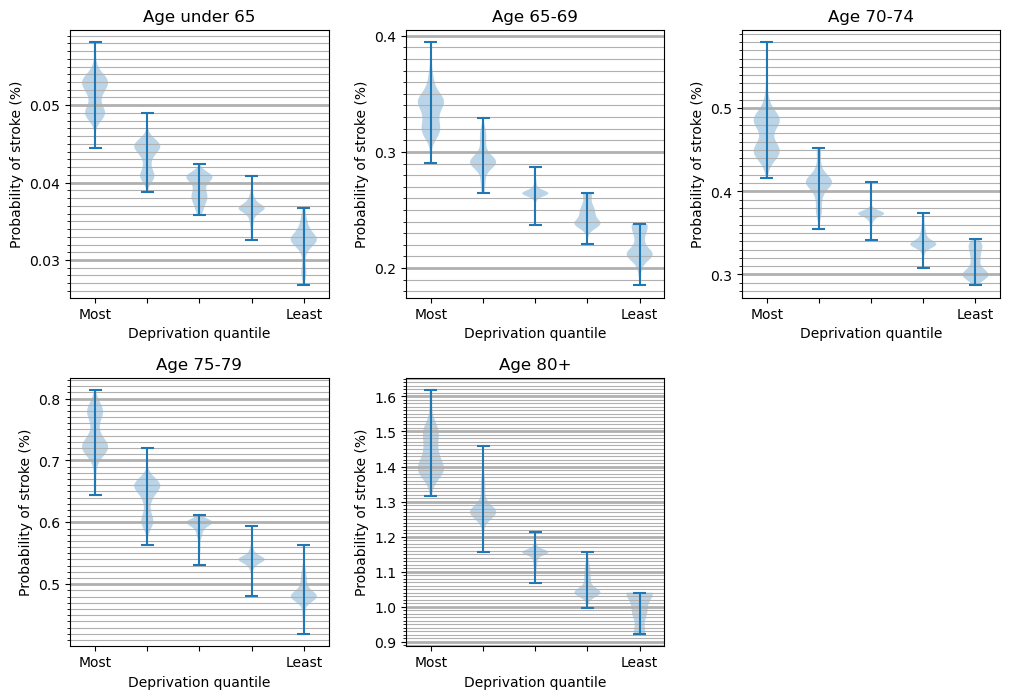

In [25]:
age_band_label_dict = {'age_less65': 'Age under 65', 'age_65': 'Age 65-69', 'age_70': 'Age 70-74', 'age_75': 'Age 75-79', 'age_over80': 'Age 80+'}
# qmin_label_dict = {'q00': '0-20%', 'q02': '20-40%', 'q04': '40-60%', 'q06': '60-80%', 'q08': '80-100%'}
qmin_label_dict = {'q00': 'Most', 'q02': '', 'q04': '', 'q06': '', 'q08': 'Least'}

fig, axs = plt.subplots(2, 3, figsize=(12, 8), gridspec_kw={'hspace': 0.3, 'wspace': 0.3})

for i in range(5):
    ax = axs[i // 3, i % 3]
    
    # for i, c in enumerate(coeff_names):
    #     ax.violinplot(df_best_gens[c], )
    coeff_names_here = coeff_names_by_age[i*5:i*5+5]
    ax.violinplot(100.0 * df_best_gens[coeff_names_here], positions=np.arange(5))

    title = age_band_label_dict['_'.join(coeff_names_here[0].split('_')[:-1])]
    ax.set_title(title)
    xticklabels = [qmin_label_dict[c.split('_')[-1]] for c in coeff_names_here]
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(xticklabels)#, rotation=30, ha='right')
    # ax.ticklabel_format(axis='y', style=None, scilimits=[-1, 0])

    # Mark every significant figure:
    tick_space = 100.0 * 1e-4 if i == 0 else 100.0 * 1e-3
    ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(tick_space))
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(tick_space*0.1))
    ax.grid(axis='y', which='both')#, linewidth=None)
    ax.grid(axis='y', which='major', linewidth=2)

    ax.set_xlabel('Deprivation quantile')
    ax.set_ylabel('Probability of stroke (%)')

axs[-1, -1].set_visible(False)

plt.savefig(os.path.join('images', 'violin_coeffs_deap_output.png'), bbox_inches='tight', dpi=200)
plt.show()

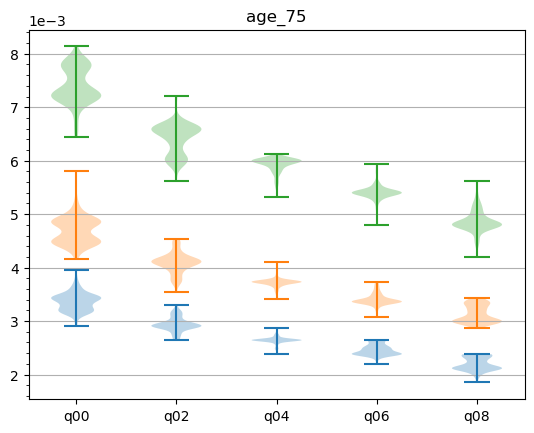

In [26]:
fig, ax = plt.subplots()

for i in range(1, 4):
    
    # for i, c in enumerate(coeff_names):
    #     ax.violinplot(df_best_gens[c], )
    coeff_names_here = coeff_names_by_age[i*5:i*5+5]
    ax.violinplot(df_best_gens[coeff_names_here], positions=np.arange(5))

    title = '_'.join(coeff_names_here[0].split('_')[:-1])
    ax.set_title(title)
    xticklabels = [c.split('_')[-1] for c in coeff_names_here]
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(xticklabels)
    ax.ticklabel_format(axis='y', style=None, scilimits=[-1, 0])

    # Mark every significant figure:
    tick_space = 1e-4 if i == 0 else 1e-3
    ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(tick_space))
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(tick_space*0.2))
    ax.grid(axis='y', which='major')
    
plt.show()

## Check best individuals

Plot to gauge the range of values:

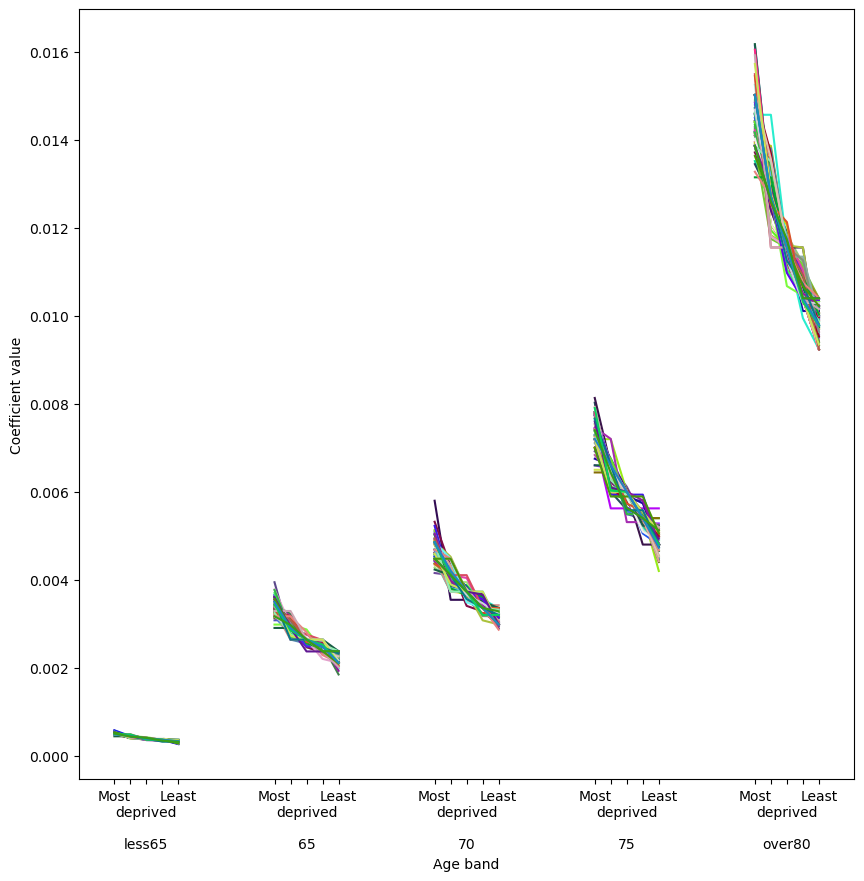

In [27]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

np.random.seed(42)
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    # if results_dir in df_best_gens_topr2['dir']:
    colour = np.random.rand(3,)
    zorder = 5
    alpha = 1.0
    # else:
    #     colour = 'silver'
    #     zorder = 4
    #     alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c]# * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1


ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')

# Save:
plt.savefig('./images/scatter_coeffs_from_deap.png', bbox_inches='tight')
plt.show()

In [ ]:
print(stop, here, please)

## Round results to 1 significant figure

See if it helps

In [19]:
labels = ['less65', '65', '70', '75', 'over80']
# round_dict = dict(zip(labels, [5, 4, 4, 4, 4]))
round_dict = dict(zip(labels, [4, 3, 3, 3, 3]))

for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = np.round(df_best_gens[coeff], round_dict[key])
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Drop fitness since it no longer applies now the data has been rounded:

In [20]:
df_best_gens = df_best_gens.drop('fitness')

In [21]:
df_best_gens

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,unique_label
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""randomseed00""",33.0,0.0005,0.003,0.005,0.007,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.006,0.011,0.0003,0.002,0.003,0.005,0.01,90
"""randomseed01""",33.0,0.0004,0.003,0.005,0.008,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,0
"""randomseed02""",43.0,0.0005,0.003,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,79
"""randomseed03""",28.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.006,0.01,0.0003,0.002,0.003,0.004,0.01,3
"""randomseed04""",39.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed95""",35.0,0.0005,0.003,0.005,0.007,0.014,0.0005,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.006,0.01,0.0003,0.002,0.003,0.005,0.01,99
"""randomseed96""",28.0,0.0005,0.003,0.005,0.009,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.006,0.01,0.0004,0.002,0.003,0.005,0.01,61
"""randomseed97""",46.0,0.0005,0.003,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,55


## Check best individuals

Plot to gauge the range of values:

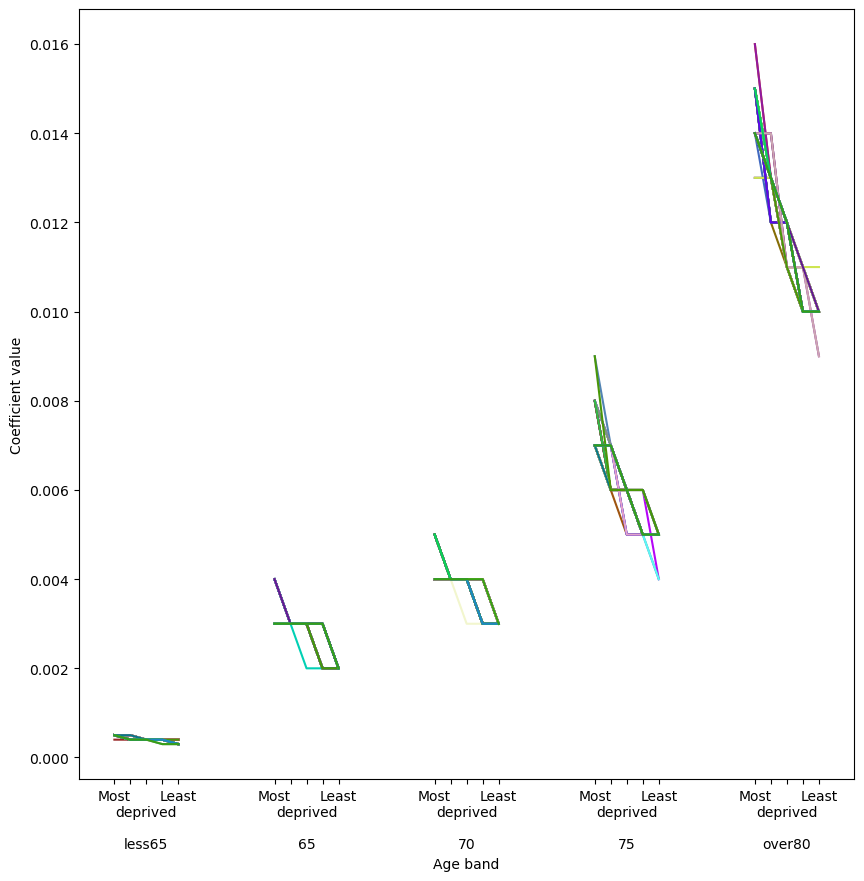

In [22]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

np.random.seed(42)
fig, ax = plt.subplots(figsize=(10, 10))

for results_dir in results_dirs_to_merge:
    # Pick out coeffs:
    coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    # if results_dir in df_best_gens_topr2['dir']:
    colour = np.random.rand(3,)
    zorder = 5
    alpha = 1.0
    # else:
    #     colour = 'silver'
    #     zorder = 4
    #     alpha = 0.4
    # g = gen_attr(df_coeffs_init)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(coeffs)[np.arange(0, 25, 5) + c]# * np.array([coeffs_ssnap[c]] * 5)
        ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, label=(results_dir if c==0 else None))
        offset += 0.1


ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')

# Save:
plt.savefig('./images/scatter_coeffs_from_deap_round1sf.png', bbox_inches='tight')
plt.show()

## Effect on admissions numbers

Check a few sets of coefficients with the best fitness. How much difference do they make to the predicted admission numbers for a few MSOA?

All 100 sets of coefficients give pretty good fitness:

In [42]:
df_best_gens.sort('fitness')['fitness'].to_numpy()

array([237.742, 237.821, 237.915, 237.986, 238.002, 238.006, 238.016,
       238.037, 238.045, 238.081, 238.173, 238.254, 238.3  , 238.328,
       238.335, 238.358, 238.36 , 238.372, 238.39 , 238.4  , 238.421,
       238.453, 238.455, 238.499, 238.507, 238.513, 238.515, 238.543,
       238.56 , 238.604, 238.609, 238.622, 238.623, 238.664, 238.666,
       238.669, 238.672, 238.696, 238.74 , 238.75 , 238.767, 238.768,
       238.786, 238.791, 238.808, 238.809, 238.819, 238.84 , 238.894,
       238.901, 238.927, 238.952, 238.973, 238.982, 239.009, 239.015,
       239.038, 239.041, 239.047, 239.051, 239.066, 239.07 , 239.111,
       239.113, 239.147, 239.161, 239.177, 239.198, 239.222, 239.224,
       239.239, 239.25 , 239.25 , 239.258, 239.272, 239.275, 239.307,
       239.308, 239.329, 239.354, 239.416, 239.419, 239.459, 239.488,
       239.49 , 239.525, 239.589, 239.639, 239.641, 239.665, 239.673,
       239.751, 239.802, 239.924, 239.936, 239.942, 239.985, 240.334,
       240.446, 240.

In [43]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [44]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


In [172]:
df_stats['admissions'].mean()

11.923122238584826

Pick out column names for the health and age proportions:

In [45]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [46]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

In [5]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

In [16]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [59]:
def predict_admissions_each_age(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (
        [(x_lists[i] * coeffs[i]) for i in range(len(coeffs))]
    )
    return yhat

In [128]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

In [78]:
age_numbers

['age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']

In [129]:
# dict_r2 = {}
# dict_admissions_pred = {}
df_all_admissions_pred = df_stats[['MSOA', 'depriv_quantile_min', 'admissions']]
dict_r2_dir = {}

for dir_name in df_best_gens['dir']:
    df = df_best_gens.filter(df_best_gens['dir'] == dir_name)[0]
    coeffs = df[coeff_names].to_numpy().flatten()
    df_admissions_here = df_stats[['MSOA', 'depriv_quantile_min', 'admissions'] + age_numbers]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', np.zeros(len(df_admissions_here))))
    for i, q in enumerate(qmin_list):
        qstr = str(round(q, 1)).replace('.', '')
        df_here = df_admissions_here.filter(df_admissions_here['depriv_quantile_min'] == q)
    
        # coeffs_q = coeffs_depriv.filter(np.round(coeffs_depriv['depriv_quantile_min'], 1) == np.round(q, 1))[cols_coeffs_depriv]#.to_numpy()
        coeffs_q = coeffs[i*5:i*5+5]
        
        for i, a in enumerate(age_numbers):
            df_here = df_here.with_columns(pl.Series('admissions_predicted', df_here['admissions_predicted'] + (coeffs_q[i] * df_here[a])))
    
        # # R2 for just this q:
        # r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_predicted'])
        # dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)
        
        mask = df_admissions_here['MSOA'].is_in(df_here['MSOA'])
    
        # df_admissions_here = df_admissions_here.with_columns(
        #    pl.when(mask)
        #      .then(df_here['admissions_predicted'])
        #      .otherwise(pl.col('admissions_predicted'))
        #      .name.keep()
        # )
        df_admissions_here = df_admissions_here.join(df_here['MSOA', 'admissions_predicted'], on='MSOA', suffix=f'_q{qstr}', how='left')
        
    cols_pred = [c for c in df_admissions_here.columns if (('q' in c) & (c.startswith('admissions_predicted')))]
    df_admissions_here = df_admissions_here.with_columns(pl.Series('admissions_predicted', df_admissions_here[cols_pred].sum_horizontal()))

    # dict_admissions_pred[dir_name] = df_admissions_here[['MSOA', 'admissions_predicted']]
    df_all_admissions_pred = df_all_admissions_pred.with_columns(df_admissions_here[['admissions_predicted']].rename({'admissions_predicted': dir_name}))
    
    # # Calculate R2:
    # r2 = calculate_rsquared(df_admissions_here['admissions'], df_admissions_here['admissions_predicted'])
    # dict_r2['r2_all'] = np.round(r2, 5)
    # Calculate residuals:
    res = find_square_residuals(df_admissions_here['admissions_predicted'], df_admissions_here['admissions'])
    # dict_r2['res'] = np.round(res, 3)
    dict_r2_dir[dir_name] = np.round(res, 5)
    

In [132]:
dict_r2_dir['randomseed00']

236.97572

In [105]:
df_best_gens['dir'].to_numpy()

array(['randomseed00', 'randomseed01', 'randomseed02', 'randomseed03',
       'randomseed04', 'randomseed05', 'randomseed06', 'randomseed07',
       'randomseed08', 'randomseed09', 'randomseed10', 'randomseed11',
       'randomseed12', 'randomseed13', 'randomseed14', 'randomseed15',
       'randomseed16', 'randomseed17', 'randomseed18', 'randomseed19',
       'randomseed20', 'randomseed21', 'randomseed22', 'randomseed23',
       'randomseed24', 'randomseed25', 'randomseed26', 'randomseed27',
       'randomseed28', 'randomseed29', 'randomseed30', 'randomseed31',
       'randomseed32', 'randomseed33', 'randomseed34', 'randomseed35',
       'randomseed36', 'randomseed37', 'randomseed38', 'randomseed39',
       'randomseed40', 'randomseed41', 'randomseed42', 'randomseed43',
       'randomseed44', 'randomseed45', 'randomseed46', 'randomseed47',
       'randomseed48', 'randomseed49', 'randomseed50', 'randomseed51',
       'randomseed52', 'randomseed53', 'randomseed54', 'randomseed55',
      

In [162]:
df_all_admissions_pred = df_all_admissions_pred.with_columns(pl.Series('mean', df_all_admissions_pred[df_best_gens['dir'].to_numpy()].mean_horizontal()))

In [164]:
df_all_admissions_pred = df_all_admissions_pred.with_columns(std = pl.concat_list(df_all_admissions_pred[df_best_gens['dir'].to_numpy()]).list.std())

In [165]:
df_all_admissions_pred = df_all_admissions_pred.with_columns(sum = pl.concat_list(df_all_admissions_pred[df_best_gens['dir'].to_numpy()]).list.sum())

In [166]:
df_all_admissions_pred = df_all_admissions_pred.with_columns(pl.Series('perc_std', 100.0 * df_all_admissions_pred['std'] / df_all_admissions_pred['mean']))

In [173]:
for col in ['admissions', 'mean', 'std', 'perc_std']:
    print(f'{df_all_admissions_pred[col].min():.3f} {df_all_admissions_pred[col].max():.3f} {df_all_admissions_pred[col].mean():.3f}')

1.000 40.333 11.923
3.672 33.738 11.926
0.057 0.505 0.164
0.957 3.919 1.398


Say some imaginary average stroke unit has 70 MSOA in its catchment area (approx 6800 MSOA by approx 100 stroke units), then what is the mean admissions and std from the various sets of coeffs?

In [170]:
len(df_stats)

6790

In [174]:
n_msoa_caught = 70
n_admissions_imag = df_all_admissions_pred['mean'].mean() * n_msoa_caught
sum_sqres_imag = np.sqrt(df_all_admissions_pred['std'].mean()**2.0 * n_msoa_caught)

print(n_admissions_imag, sum_sqres_imag)

834.8176598645106 1.3699075895632744


In [135]:
df_all_admissions_pred['sum']

sum
f64
1426.345114
1141.346835
1145.232215
1820.309439
1435.289983
…
1113.975273
1020.237329
1493.429403


In [116]:
df_all_admissions_pred

MSOA,depriv_quantile_min,admissions,randomseed00,randomseed01,randomseed02,randomseed03,randomseed04,randomseed05,randomseed06,randomseed07,randomseed08,randomseed09,randomseed10,randomseed11,randomseed12,randomseed13,randomseed14,randomseed15,randomseed16,randomseed17,randomseed18,randomseed19,randomseed20,randomseed21,randomseed22,randomseed23,randomseed24,randomseed25,randomseed26,randomseed27,randomseed28,randomseed29,randomseed30,randomseed31,randomseed32,randomseed33,…,randomseed66,randomseed67,randomseed68,randomseed69,randomseed70,randomseed71,randomseed72,randomseed73,randomseed74,randomseed75,randomseed76,randomseed77,randomseed78,randomseed79,randomseed80,randomseed81,randomseed82,randomseed83,randomseed84,randomseed85,randomseed86,randomseed87,randomseed88,randomseed89,randomseed90,randomseed91,randomseed92,randomseed93,randomseed94,randomseed95,randomseed96,randomseed97,randomseed98,randomseed99,mean,std,perc_std
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",0.4,14.333333,14.263677,14.423034,14.341673,14.358757,14.133485,14.474412,14.469944,14.249524,14.222718,14.163114,14.230514,13.919964,14.380567,14.236639,14.327513,14.342617,14.425211,13.93102,14.240589,14.287394,14.423034,14.375162,14.219465,14.2716,14.324594,14.369242,14.063629,14.159806,14.271862,14.349424,14.165525,14.307028,14.119663,14.271109,…,14.312891,14.423034,14.423034,14.298462,14.442577,14.261613,14.234901,14.250911,14.426445,14.318496,13.970185,13.986857,14.127375,14.286949,14.359209,14.490831,14.380592,14.204928,13.967385,14.557615,14.159641,14.057812,14.380973,14.434359,14.143073,14.198181,14.049216,14.420203,14.465477,14.053506,14.012231,14.273087,14.414099,14.414099,14.263451,0.14564,1.021073
"""Adur 002""",0.8,7.333333,11.168497,11.38405,11.361935,11.052673,11.364037,11.464191,11.404827,11.595126,11.127011,11.580143,11.429903,11.687325,11.234761,11.163724,11.32541,11.608737,11.279424,11.354035,11.522715,11.393395,11.645044,11.465456,11.511574,11.623703,11.435876,11.565005,11.58718,11.359733,11.282647,11.361749,11.131442,11.423131,11.542934,11.640157,…,11.527577,11.055034,11.456918,11.787221,11.373797,11.296981,11.897775,11.350352,11.247793,11.193251,11.523999,11.380011,11.270695,11.598921,11.584253,11.080888,11.558952,11.334745,11.484388,11.368559,11.1173,11.515532,11.477776,11.383991,11.302954,11.579392,11.112133,11.393642,11.293691,11.3426,11.531212,11.415311,11.44432,11.311506,11.413468,0.16921,1.482544
"""Adur 003""",0.6,9.333333,11.583681,11.466481,11.522126,11.453605,11.468124,11.321341,11.423034,11.430163,11.58812,11.78478,11.39555,11.336827,11.390431,11.517786,11.321341,11.337891,11.334367,11.411433,11.192456,11.394758,11.466931,11.321341,11.473252,11.414724,11.434344,11.321341,11.314947,11.332496,11.563169,11.498162,11.437192,11.412663,11.71986,11.528519,…,11.641535,11.385284,11.412579,11.341446,11.496594,11.472162,11.259529,11.515155,11.472357,11.471785,11.366217,11.579499,11.467418,11.391205,11.343581,11.550058,11.790953,11.371243,11.349102,11.504545,11.598123,11.254089,11.231359,11.511749,11.437924,11.532595,11.82354,11.481891,11.444944,11.374495,11.351088,11.508981,11.439755,11.434579,11.452322,0.129042,1.126774
"""Adur 004""",0.2,21.0,18.077486,18.147175,18.158141,18.454246,18.271763,17.698631,18.000835,18.126186,18.277841,17.998427,17.990999,18.062769,18.36843,18.051872,18.326746,18.049079,18.196569,17.984408,18.259232,18.191479,17.902716,18.225597,17.97846,18.191466,18.326746,18.207512,18.281782,18.530357,18.419118,18.49856,18.773433,18.342399,17.672621,17.881805,…,18.134647,18.438066,18.169299,18.351973,18.326746,18.363657,17.886066,18.161788,18.160033,18.211303,18.497455,18.220179,18.093537,17.778935,18.28929,18.015658,17.813861,18.548069,18.456487,18.261796,18.

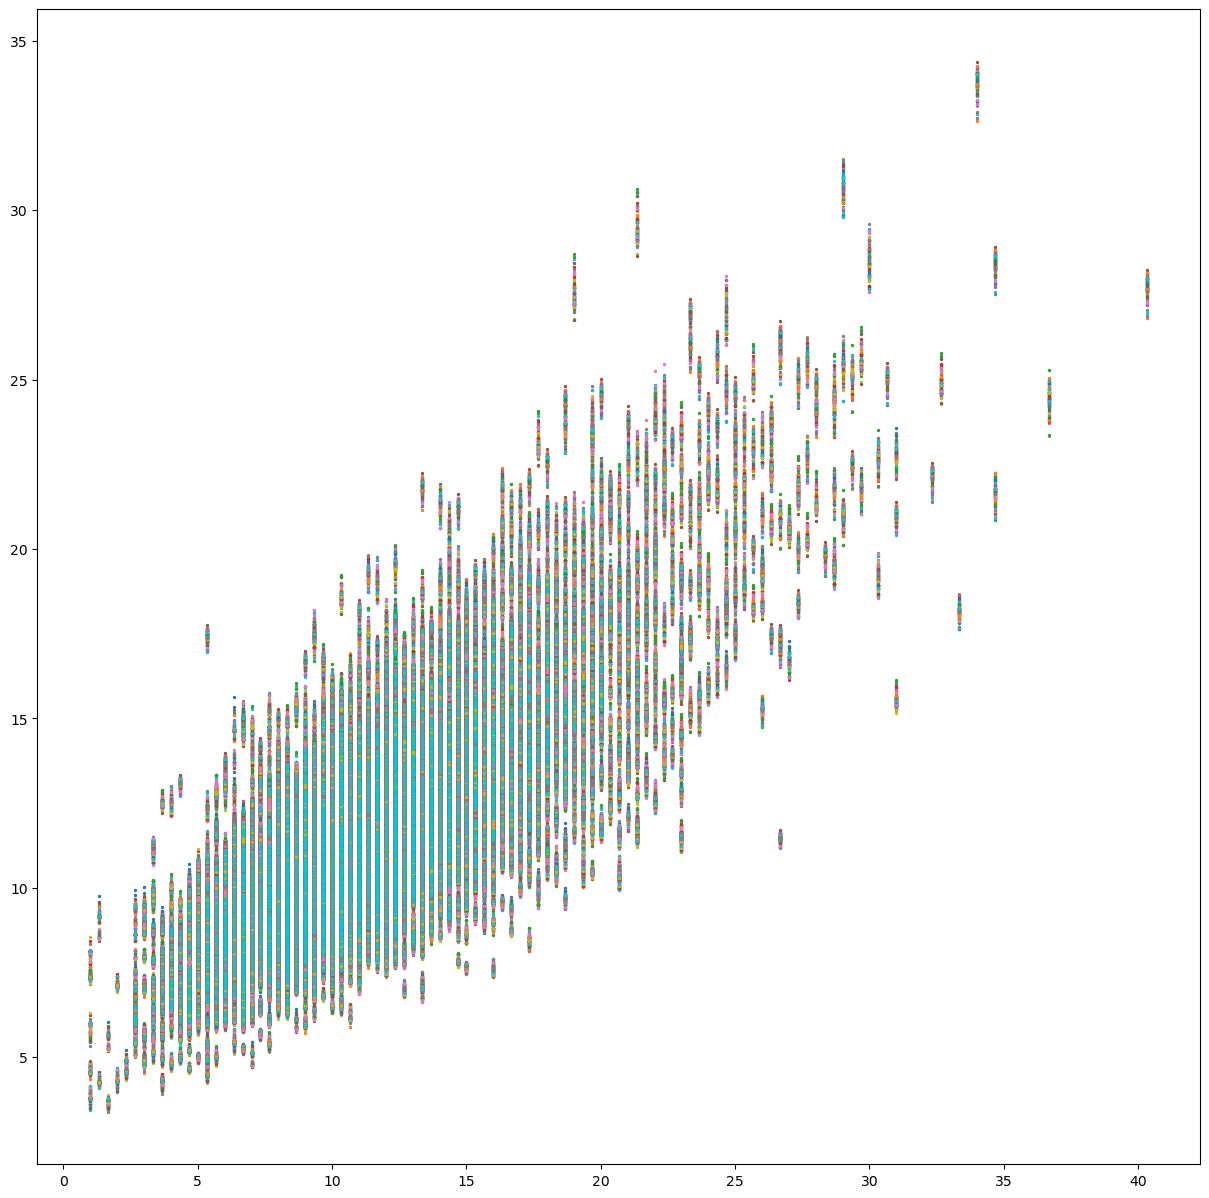

In [96]:
fig, ax = plt.subplots(figsize=(15, 15))
for key, df in dict_admissions_pred.items():
    ax.scatter(df['admissions'], df['admissions_predicted'], s=2)
plt.show()

In [93]:
df_sum = pl.DataFrame()

for key, df in dict_admissions_pred.items():
    df_here = (df[['admissions', 'admissions_predicted']].sum())
    df_here = df_here.with_columns(pl.Series('perc', 100.0 * (df_here['admissions_predicted'] - df_here['admissions']) / df_here['admissions']))
    df_sum = pl.concat((df_sum, df_here))

In [139]:
england_sums = df_all_admissions_pred.sum()[df_best_gens['dir'].to_numpy()].to_numpy().flatten()

print(np.mean(england_sums), np.std(england_sums))

80977.31300685753 69.85980991491341


In [140]:
england_sums

array([80978.11551527, 80914.56888078, 80960.13128923, 81126.04108212,
       80998.63509491, 80959.78000825, 81013.06354129, 80945.68070265,
       80889.47557608, 80882.32857117, 80912.95501651, 80902.15409736,
       81148.02409532, 81148.63706242, 80868.73548311, 81062.39949773,
       80934.57175921, 80877.72339648, 80911.48251484, 81024.43574304,
       81010.73454011, 81018.45298025, 81023.39368597, 81043.73292213,
       80896.61184012, 81057.23062643, 81030.44234951, 80987.32492526,
       80979.85673986, 80946.20958981, 81008.90043747, 81014.92196714,
       80887.52997047, 81033.50427874, 80856.35230489, 80933.18809446,
       80974.83146582, 80902.55067842, 81066.85519989, 80988.00148615,
       80954.90844085, 80961.15626831, 81034.05791151, 80836.21845596,
       80962.69691843, 80892.55659362, 80974.1851329 , 81049.54246248,
       81035.15544213, 81007.91141765, 80928.44290169, 80989.31652567,
       81064.50562589, 81101.43629083, 80972.73778694, 81006.98514498,
      

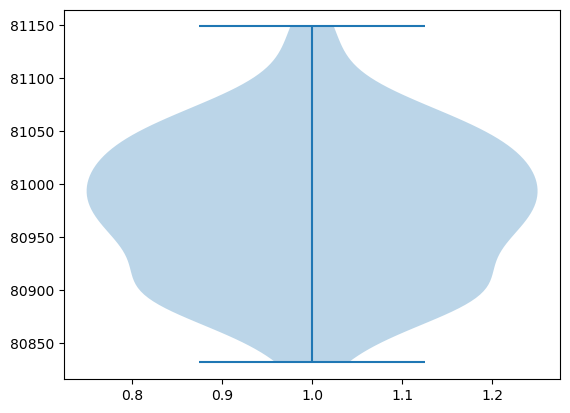

In [141]:
plt.violinplot(england_sums)
plt.show()

In [94]:
df_sum

admissions,admissions_predicted,perc
f64,f64,f64
80958.0,80978.115515,0.024847
80958.0,80914.568881,-0.053646
80958.0,80960.131289,0.002633
80958.0,81126.041082,0.207566
80958.0,80998.635095,0.050193
…,…,…
80958.0,80958.594,0.000734
80958.0,80831.517508,-0.156232
80958.0,81058.751729,0.124449


{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7f74214d2890>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7f74299c7d00>,
 'cmins': <matplotlib.collections.LineCollection at 0x7f7421010130>,
 'cbars': <matplotlib.collections.LineCollection at 0x7f7421010760>}

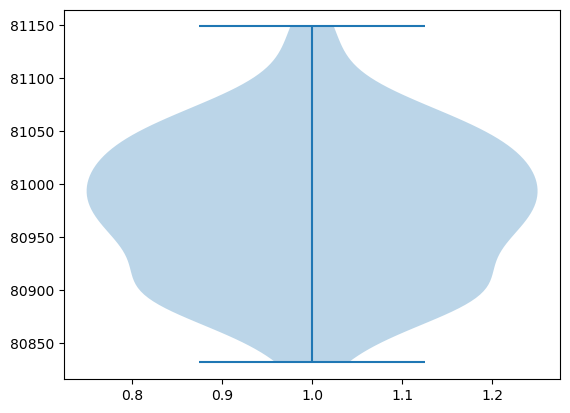

In [90]:
plt.violinplot(df_sum['admissions_predicted'])
plt.show()

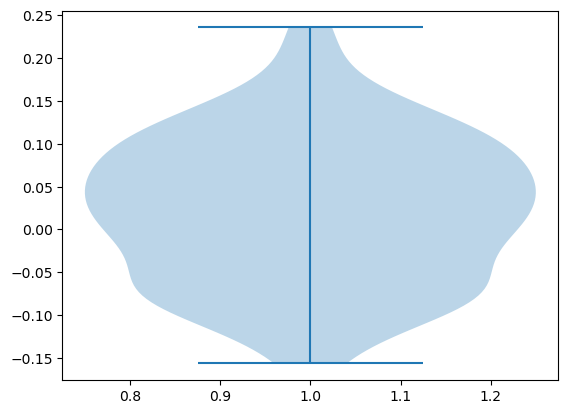

In [95]:
plt.violinplot(df_sum['perc'])
plt.show()